### Simulation parameters


In [1]:
from utils import (
    omega_c,
    default_three_phase_protocol,
)

%load_ext autoreload
%autoreload 2

N = 20
gamma = 1.0
Omega_ratio = 0.4
delta0 = 1.0

N_J = N // 2
Omega0 = Omega_ratio * omega_c(N_J, gamma)

# Define the three-phase protocol with the desired parameters.
phases = default_three_phase_protocol(
    T1=10.0,
    T2=10.0,
    T3=10.0,
    delta0=delta0,
    Omega0=Omega0,
)


### Quantum Trajectories

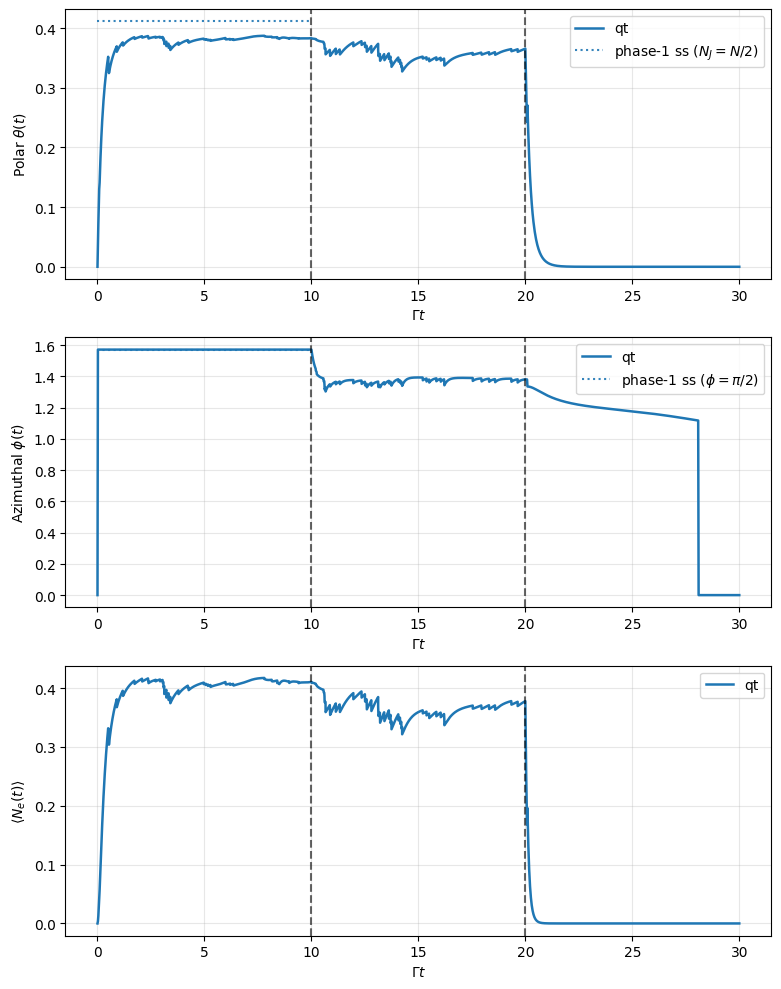

In [4]:
from quantum_trajectories.state_helpers import (
    centered_sector_initial_coeffs,
)
from quantum_trajectories.sim import (
    simulate_nj_sector_trajectory,
)
from quantum_trajectories.plotting import (
    plot_trajectory_angles_and_excitation,
)

seed = 1234
dt = 1e-3
save_every = 20

# Returns a dictionary of key: sector Nj, value: coefficient for that sector. 
sector_coeffs = centered_sector_initial_coeffs(N, half_width=5)

# Simulate a single trajectory
result = simulate_nj_sector_trajectory(
    N=N,
    gamma=gamma,
    phases=phases,
    sector_coeffs=sector_coeffs,
    dt=dt,
    save_every=save_every,
    seed=seed,
)

fig, axes = plot_trajectory_angles_and_excitation(result, phases)

# Simulate an ensemble of trajectories and compute the average observables
# ensemble = run_trajectory_ensemble(
#     N=N,
#     gamma=gamma,
#     phases=phases,
#     sector_coeffs=sector_coeffs,
#     ntraj=50,
#     dt=dt,
#     save_every=save_every,
#     seed=seed,
# )

# avg = ensemble_observables(ensemble)
# fig1, axes = plot_ensemble_angles_and_excitation(
#     avg,
#     phases,
#     N=N,
#     gamma=gamma,
# )

### Qutip Quantum Trajectories

In [5]:
from quantum_trajectories_qutip.sim import (
    simulate_fixed_nj_me_trajectory,
    simulate_fixed_nj_mc_trajectory
)
from quantum_trajectories_qutip.plotting import (
    plot_qutip_angles_and_excitation,
)

qt_data = simulate_fixed_nj_mc_trajectory(
    N=N,
    gamma=gamma,
    phases=phases,
    num_points=600,
    ntraj=1,
    seed=1234,
)

fig, axes = plot_qutip_angles_and_excitation(
    qt_data,
    phases,
    N=N,
    gamma=gamma,
)

ImportError: cannot import name 'phase_change_times' from 'utils' (/Users/ashar/Documents/Github/cavity-OAT/utils.py)

In [ ]:
# from squeezing_parameter import plot_generalized_xi

# %load_ext autoreload
# %autoreload 2

# # Steady state angles
# theta_ss, phi_ss = phase1_ss_angles_for_nj(N_J, Omega0, gamma)

# # tilde_theta, tilde_phi are the phase-1 reference angles used to define |1>
# xi_data, fig, ax = plot_generalized_xi(
#     result,
#     phases,
#     tilde_theta=theta_ss,
#     tilde_phi=phi_ss,
#     output_path="generalized_xi.png",
# )